## rSVD Test Problem Setup

This notebook introduces the three test problems which I consider in the thesis, referred to as problem I, II,  and III. I test out selected rSVD approximations against the true weighted Tikhonov solution.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from fenics import plot
from pathlib import Path
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W

from utils.colors import CMAP
from utils.problem_setup import TestProblemsSetup
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit


plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15

In [2]:
setup = TestProblemsSetup(n=64)
problems = setup.get_test_problems()
problem_params = setup.problem_params

../../figures/problem_illustration.png already exists


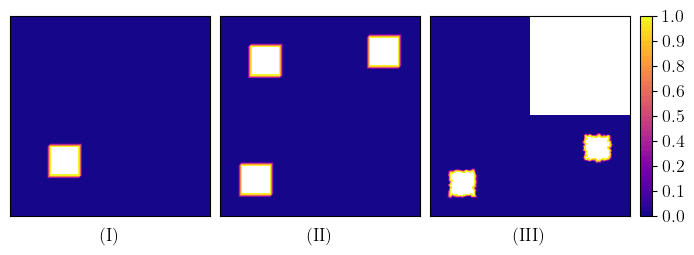

In [3]:
def save_plot(fig_name: str) -> None:
    if fig_name is not None:
        path = Path(f"../../figures/{fig_name}.png")
        if not path.exists():
            plt.savefig(path, dpi=300, bbox_inches="tight")
        else:
            print(path, 'already exists')
    

def figure_problems(problems, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))

    labels = ["(I)", "(II)", "(III)"]

    for ax, prob, label in zip(axes, ['I', 'II', 'III'], labels):
        f = problems[prob]['f']
        plt.sca(ax)
        p = plot(f, cmap=CMAP)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.text(
            0.5, -0.057, label,
            transform=ax.transAxes,
            ha="center",
            va="top"
        )

    #fig.colorbar(p, ax=ax, location="right", format="%.2f", shrink=0.85)
    cax = fig.add_axes([0.913, 0.162, 0.015, 0.666]) # [left, bottom, width, height]
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    fig.colorbar(p, cax=cax, format="%.1f", norm=norm, shrink=0.8)
    #plt.subplots_adjust(wspace=0.07, right=0.9)

    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.05)
    save_plot(fig_name)
    plt.show()


figure_problems(problems, fig_name='problem_illustration')

In [13]:
def selected_solutions(pid: 'str', problems: dict, k_selected: list):
    from utils.solvers import fast_rsvd_solver
    pb = problems[pid]
    
    # Compute the exact weighted Tikhonov solution
    exact = ExactForwardOperator(pb['V_h'])
    f_hat = solve_explicit(
        operator=exact,
        w=exact.get_weights(),
        y=pb['y'],
        lambda_=1e-4
    )

    # List of selected solutions
    f_selected = [f_hat]

    # Compute selected rank-k solutions
    rsvd: MatrixFreeRSVD = pb['rsvd']
    for k in k_selected:
        rsvd.mf_rsvd(k=k, seed=SEED, p=5)
        f_hat = fast_rsvd_solver(
            y=pb['y'],
            w=get_approximate_W(rsvd.VkT.T, rsvd.M_dx),
            lam=1e-4,
            rsvd=rsvd
        )
        f_selected.append(f_hat)

    return f_selected

In [10]:
def plot_solutions(f_list, params, fig_name=None):
    width = params['width']
    height = params['height']
    x0s, y0s = params['x0'], params['y0']

    import matplotlib.patches as patches

    fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)
    axes = axes.flatten()

    # Global color scale
    #import matplotlib.colors as mcolors
    #vmin = min(fi.vector().min() for fi in f_list)
    #vmax = max(fi.vector().max() for fi in f_list)
    #norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for ax, fi in zip(axes, f_list):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP) #, norm=norm)

        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.655)

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    #fig.colorbar(p, ax=axes, format="%.2f", shrink=0.772, location='right', pad=0.0095)
    save_plot(fig_name)
    plt.show()

../../figures/test_problem_I.png already exists


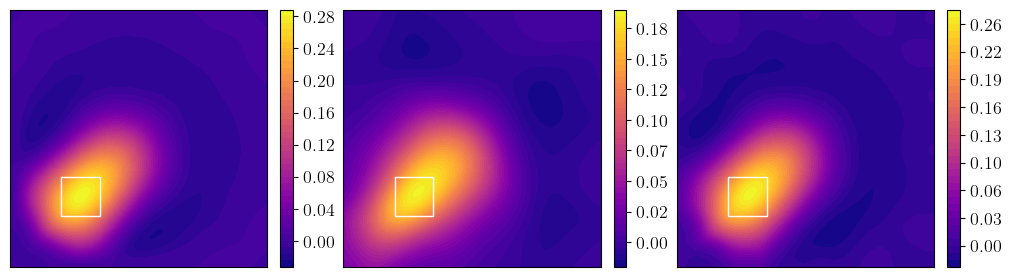

../../figures/test_problem_II.png already exists


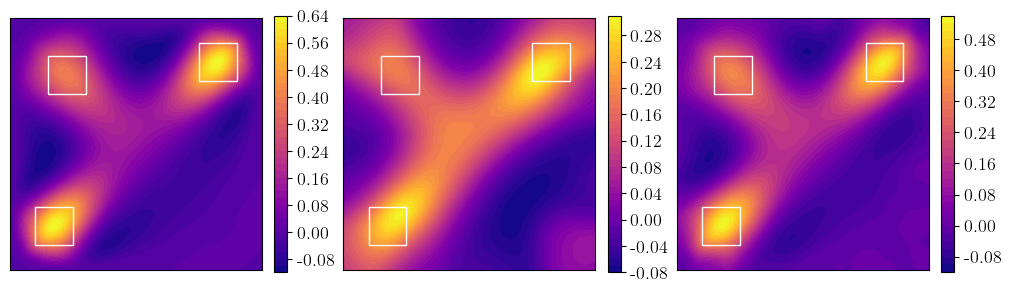

../../figures/test_problem_III.png already exists


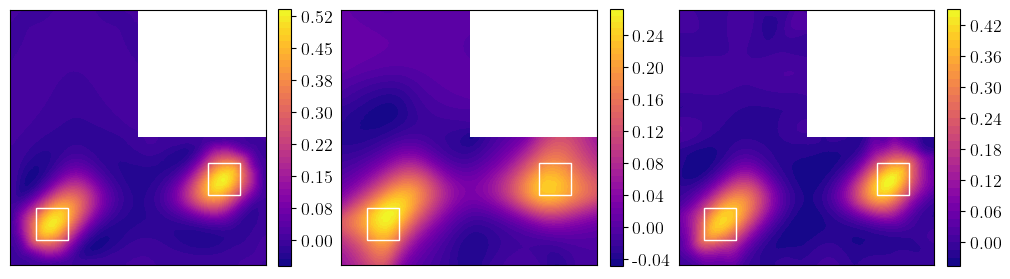

In [15]:
for pid in ('I', 'II', 'III'):
    f_selected = selected_solutions(
        pid=pid,
        problems=problems,
        k_selected=[10, 30]
    )
    plot_solutions(f_selected, problem_params[pid], fig_name=f'test_problem_{pid}')
